
# BLOCK 1: Importing modules

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from google.oauth2 import service_account
!pip install pandas-gbq db-dtypes

# BLOCK 2: Set up data connexion

In [108]:
KEY_PATH = "../keys/bigquery_key.json"
credentials = service_account.Credentials.from_service_account_file(KEY_PATH)
client = bigquery.Client(credentials=credentials, project=credentials.project_id) 

# BLOCK 3: Load the dataset

In [ ]:
query = """
SELECT * FROM `tranquil-gasket-457509-b3.CGDA.fct_drug_sensitivity_merge`
"""

df_merged = client.query(query).to_dataframe()

# BLOCK 4: Exploratory Data Analysis (EDA)

### A. Statistical Profiling & Target Distribution

In [110]:
df_merged.describe()


,COSMIC_ID,DRUG_ID,LN_IC50_CAPPED,Z_SCORE,AUC,RMSE,MIN_CONC,MAX_CONC
count,242036.0,242036.0,242036.000000,2.420360e+05,242036.000000,242036.000000,242036.000000,242036.000000
mean,992105.875721,1594.042444,1.237425,7.312962e-10,0.882592,0.082779,0.023143,23.462279
std,220981.856696,398.740714,1.968968,9.993925e-01,0.146998,0.042695,0.158738,158.622810
min,683667.0,1003.0,-8.747724,-8.254501e+00,0.006282,0.003274,0.000010,0.010000
25%,906805.0,1149.0,0.643096,-6.568485e-01,0.849449,0.051107,0.003002,3.000000
50%,909720.0,1631.0,2.302585,1.058000e-02,0.944196,0.076083,0.010005,10.000000
75%,1240144.0,1912.0,2.302585,6.560362e-01,0.974934,0.106105,0.010005,10.000000
max,1789883.0,2499.0,7.600902,7.978776e+00,0.998904,0.299984,2.001054,2000.000000


### B. Target Distribution & Censorship Analysis

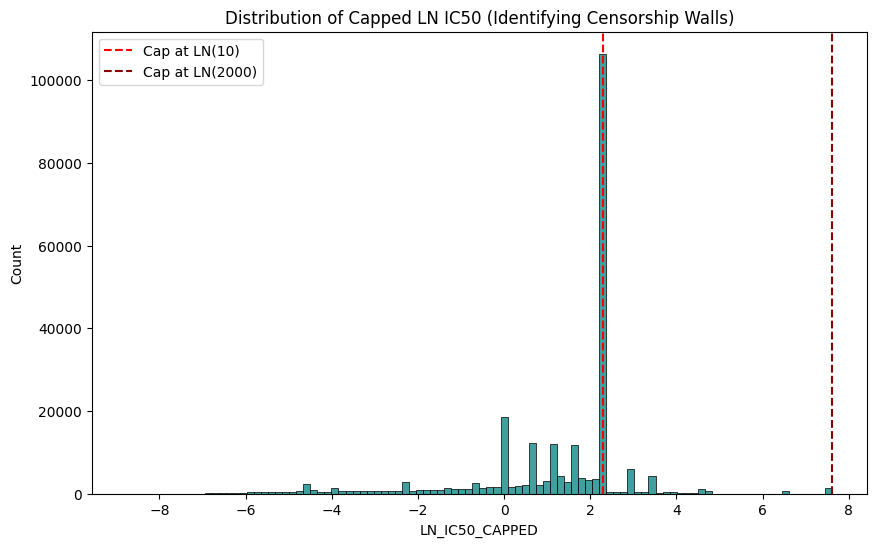

In [111]:
plt.figure(figsize=(10, 6))
sns.histplot(df_merged['LN_IC50_CAPPED'], bins=100, kde=False, color='teal')
plt.axvline(2.3, color='red', linestyle='--', label='Cap at LN(10)')
plt.axvline(7.6, color='darkred', linestyle='--', label='Cap at LN(2000)')
plt.title('Distribution of Capped LN IC50 (Identifying Censorship Walls)')
plt.legend()
plt.show()

#### Key Takeaways from Distribution Analysis

After visualising the `LN_IC50_CAPPED` distribution, we can draw three major conclusions:

##### 1. The "Maximum Concentration" Standard
The massive tower at $LN(10) \approx 2.3$ is the most significant finding. 
* **Observation:** Over 100,000 experiments were capped at a max concentration of 10.
* **Impact:** This indicates a common experimental limit. A standard linear regression model might struggle with this "spike" and attempt to predict exactly 2.3 for a wide range of resistant samples.
##### 2. Evidence of Multiple Experimental Protocols
We observe smaller spikes at approximately $0$, $0.7$, $1.2$, and $1.6$.
* **Observation:** These secondary "walls" confirm the dataset is a meta-analysis of multiple labs or panels using different dose ranges. 
* **Impact:** Standardising these limits using the $LN(MAX\_CONC)$ logic was essential for creating a consistent feature set across varied protocols.
##### 3. The "Sensitive" Tail
To the left of 0, the data follows a natural bell-curve distribution. 
* **Observation:** These represent the "Sensitive" samples where the drug effectively killed cell lines within the tested range.
* **Impact:** This is our highest-quality data for regression. The model will likely be more accurate at predicting sensitivity levels than specific resistance levels, which are squashed against the censorship walls.

##### Approach
We create a binary 'Censored' flag to inform the model that these data points represent experimental detection limits rather than precise biological measurements, allowing the algorithm to distinguish between a measured $IC_{50}$ and a right-censored resistance cap.

In [112]:
# Create a flag so the model knows which data is 'Censored'
df_merged['IS_RESISTANT_LIMIT'] = (df_merged['LN_IC50_CAPPED'] >= (df_merged['MAX_CONC'].apply(np.log) - 0.1)).astype(int)

### C. Z-Score Outlier Mitigation

* **Observation:** The Z_SCORE column contains extreme values ranging from $-8.25$ to $+7.97$. In biological assays, values nearing $\pm 8$ typically represent experimental artifacts or technical noise rather than true variance.
* **Action:** We implemented Winsorization (Clipping) at a threshold of $\pm 4$.
* **Rationale:** To prevent extreme "tails" from disproportionately biasing the model's weights during training.Method: By clipping instead of dropping, we retain the "extreme" signal (knowing the point is an outlier) without the "noise" of its specific magnitude.
* **Result:** Values $> 4$ are reset to $4$, and values $< -4$ are reset to $-4$.

Original Z-Score Range: [-8.25, 7.98]
Cleaned Z-Score Range:  [-4.00, 4.00]


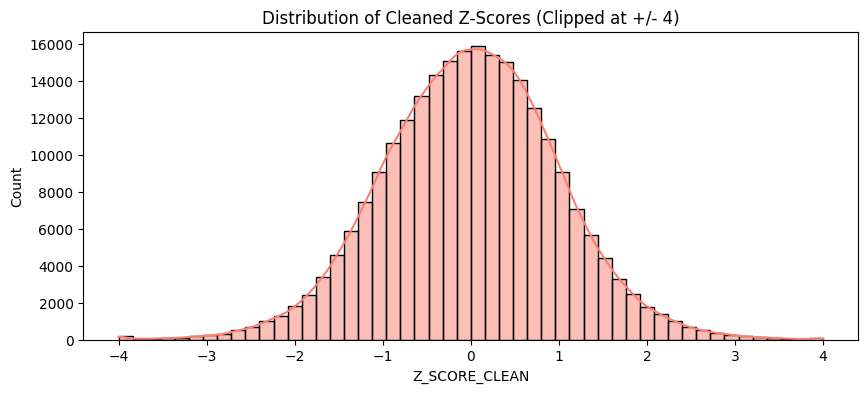

In [113]:
# 1. Apply clipping (Winsorization) at +/- 4
df_merged['Z_SCORE_CLEAN'] = df_merged['Z_SCORE'].clip(lower=-4, upper=4)

# 2. Print verification
print(f"Original Z-Score Range: [{df_merged['Z_SCORE'].min():.2f}, {df_merged['Z_SCORE'].max():.2f}]")
print(f"Cleaned Z-Score Range:  [{df_merged['Z_SCORE_CLEAN'].min():.2f}, {df_merged['Z_SCORE_CLEAN'].max():.2f}]")

# 3. Quick Visual Check
plt.figure(figsize=(10, 4))
sns.histplot(df_merged['Z_SCORE_CLEAN'], bins=50, kde=True, color='salmon')
plt.title('Distribution of Cleaned Z-Scores (Clipped at +/- 4)')
plt.show()


### D. Null value audit

In [130]:
# Find out if there are missing values in each column
null_counts = df_merged.isnull().sum()
null_percent = (null_counts / len(df_merged)) * 100 

# Combine into a quick report
null_report = pd.DataFrame({'Missing Rows': null_counts, 'Percent': null_percent})
print(null_report[null_report['Missing Rows'] > 0 ])

# there are no null values

Empty DataFrame
Columns: [Missing Rows, Percent]
Index: []


### E. Data Sparsity

#### Drug data sparsity

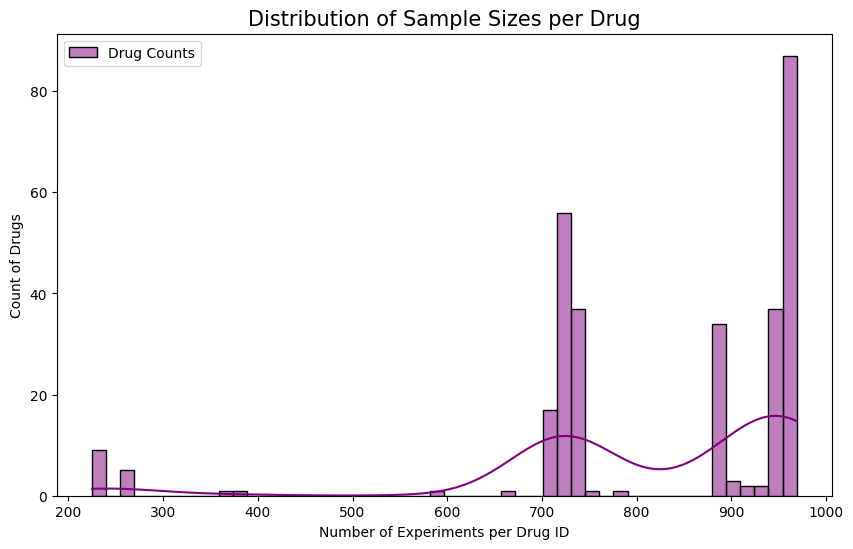

Total Unique Drugs: 295
Drugs with > 100 samples: 295
Drugs with < 20 samples: 0


In [132]:
# 1. Count how many times each drug appears
drug_counts = df_merged['DRUG_ID'].value_counts()

# 2. Plot the distribution of those counts
plt.figure(figsize=(10, 6))
sns.histplot(drug_counts, bins=50, kde=True, color='purple', label='Drug Counts')
plt.legend()

#plt.axvline(x=100, color='red', linestyle='--', label='Reliability Threshold (100 samples)')

plt.title('Distribution of Sample Sizes per Drug', fontsize=15)
plt.xlabel('Number of Experiments per Drug ID')
plt.ylabel('Count of Drugs')
plt.legend()
plt.show()



# Quick summary stats
print(f"Total Unique Drugs: {len(drug_counts)}")
print(f"Drugs with > 100 samples: {(drug_counts > 100).sum()}")
print(f"Drugs with < 20 samples: {(drug_counts < 20).sum()}")

# There are enough experimental counts per drug. 

#### TCGA labels data sparsity

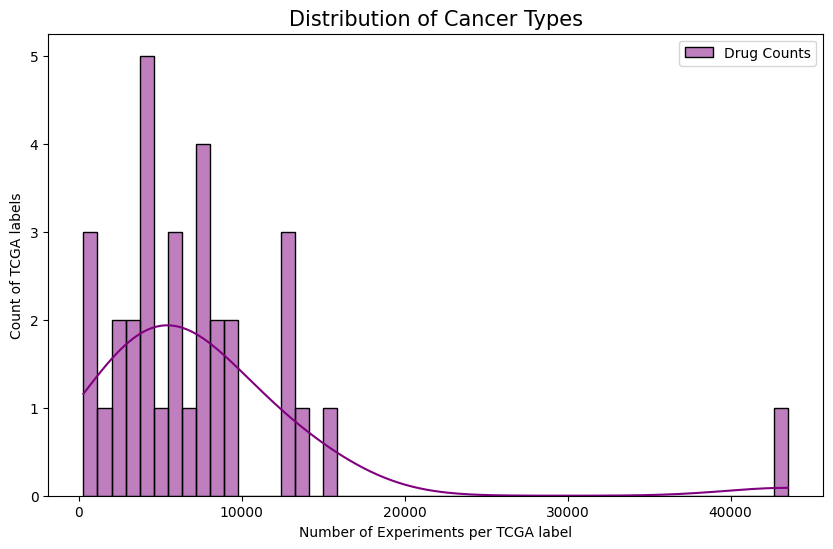

Total Unique tcga labels: 32
tcga labels with > 100 samples: 32
tcga labels with < 50 samples: 0


In [133]:
# Check the distribution of TCGA Labels
tcga_counts = df_merged['TCGA_LABEL'].value_counts()


# 2. Plot the distribution of those counts
plt.figure(figsize=(10, 6))
sns.histplot(tcga_counts, bins=50, kde=True, color='purple', label='Drug Counts')
plt.legend()

#plt.axvline(x=100, color='red', linestyle='--', label='Reliability Threshold (100 samples)')

plt.title('Distribution of Cancer Types', fontsize=15)
plt.xlabel('Number of Experiments per TCGA label')
plt.ylabel('Count of TCGA labels')
plt.legend()
plt.show()

# Quick summary stats
print(f"Total Unique tcga labels: {len(tcga_counts)}")
print(f"tcga labels with > 100 samples: {(tcga_counts > 100).sum()}")
print(f"tcga labels with < 50 samples: {(tcga_counts < 50).sum()}")



In [117]:
# Create a simple table to see the top and bottom cancer types
tcga_summary = df_merged['TCGA_LABEL'].value_counts().reset_index()
tcga_summary.columns = ['Cancer Type', 'Total Experiments']

print("--- The Top 5 (The Power Players) ---")
print(tcga_summary.head(5))

print("\n--- The Bottom 5 (The Rarest) ---")
print(tcga_summary.tail(5))

# There are enough data for all TCGA labels. The most abundant is Unkown. 

--- The Top 5 (The Power Players) ---
  Cancer Type  Total Experiments
0      Unkown              43513
1        LUAD              15653
2        SCLC              13750
3        BRCA              13106
4   COAD/READ              12718

--- The Bottom 5 (The Rarest) ---
   Cancer Type  Total Experiments
27        UCEC               2512
28        PRAD               1676
29          MB               1072
30         CLL                550
31         ACC                279


In [118]:
# 1. Fix 'Unkown' typo 
df_merged['TCGA_LABEL'] = df_merged['TCGA_LABEL'].replace('Unkown', 'Unknown')

#### Primary site data sparsity

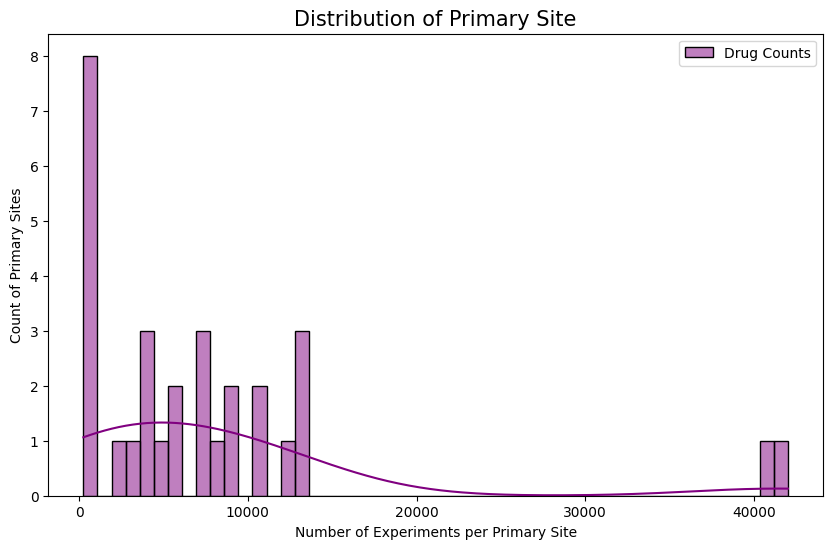

Total Unique Primary Sites: 30
Primary Sites with > 100 samples: 30
Primary Sites < 50 samples: 0


In [134]:
# Check the distribution of Primary Sites
primary_site = df_merged['PRIMARY_SITE'].value_counts()


# 2. Plot the distribution of those counts
plt.figure(figsize=(10, 6))
sns.histplot(primary_site, bins=50, kde=True, color='purple', label='Drug Counts')
plt.legend()

#plt.axvline(x=100, color='red', linestyle='--', label='Reliability Threshold (100 samples)')

plt.title('Distribution of Primary Site', fontsize=15)
plt.xlabel('Number of Experiments per Primary Site')
plt.ylabel('Count of Primary Sites')
plt.legend()
plt.show()

# Quick summary stats
print(f"Total Unique Primary Sites: {len(primary_site)}")
print(f"Primary Sites with > 100 samples: {(primary_site > 100).sum()}")
print(f"Primary Sites < 50 samples: {(primary_site < 50).sum()}")



In [120]:
# Create a simple table to see the top and bottom cancer types
primary_summary = df_merged['PRIMARY_SITE'].value_counts().reset_index()
primary_summary.columns = ['Primary Site', 'Total Experiments']

print("--- The Top 5 (The Power Players) ---")
print(primary_summary.head(5))

print("\n--- The Bottom 5 (The Rarest) ---")
print(primary_summary.tail(5))

# There are enough data for all Primary Sites. The TCGA Labels marked as Unkown have a primary site. 

--- The Top 5 (The Power Players) ---
                         Primary Site  Total Experiments
0  haematopoietic_and_lymphoid_tissue              42010
1                                lung              40897
2                              breast              13388
3                                skin              13176
4              central_nervous_system              13073

--- The Bottom 5 (The Rarest) ---
       Primary Site  Total Experiments
25           testis                619
26   salivary_gland                558
27         placenta                358
28    adrenal_gland                279
29  small_intestine                255


In [121]:
# 1. Clean up the strings from Primary Sites: Remove underscores and capitalize each word
# 'haematopoietic_and_lymphoid_tissue' -> 'Haematopoietic And Lymphoid Tissue'
df_merged['PRIMARY_SITE_CLEAN'] = df_merged['PRIMARY_SITE'].str.replace('_', ' ').str.title()

# 2. Check the result
print(df_merged['PRIMARY_SITE_CLEAN'].value_counts().head(5))

PRIMARY_SITE_CLEAN
Haematopoietic And Lymphoid Tissue    42010
Lung                                  40897
Breast                                13388
Skin                                  13176
Central Nervous System                13073
Name: count, dtype: int64


### Cleaning Unkown category from TCGA_LABEL

In [122]:
# Check: What are the organs for the 'Unknown' TCGA labels?
unknown_mask = df_merged['TCGA_LABEL'] == 'Unknown'
organs_in_unknown = df_merged[unknown_mask]['PRIMARY_SITE_CLEAN'].value_counts()

print("--- Organ Distribution for 'Unknown' TCGA Labels ---")
print(organs_in_unknown)

# Check: Does 'Haematopoietic And Lymphoid Tissue' have ANY other TCGA labels?
hemes_mask = df_merged['PRIMARY_SITE_CLEAN'] == 'Haematopoietic And Lymphoid Tissue'
tcga_for_hemes = df_merged[hemes_mask]['TCGA_LABEL'].value_counts()

print("\n--- TCGA Labels assigned to Blood Cancers ---")
print(tcga_for_hemes)

--- Organ Distribution for 'Unknown' TCGA Labels ---
PRIMARY_SITE_CLEAN
Haematopoietic And Lymphoid Tissue    13546
Bone                                  10772
Lung                                   5863
Soft Tissue                            5456
Ovary                                  1430
Biliary Tract                          1008
Stomach                                 929
Testis                                  619
Endometrium                             558
Skin                                    539
Prostate                                458
Vulva                                   360
Placenta                                358
Breast                                  282
Salivary Gland                          279
Upper Aerodigestive Tract               279
Cervix                                  268
Small Intestine                         255
Pancreas                                254
Name: count, dtype: int64

--- TCGA Labels assigned to Blood Cancers ---
TCGA_LABEL
Unknown 

In [123]:
# 1. Creating a copy to work on
df_merged['ANALYSIS_LABEL'] = df_merged['TCGA_LABEL']

# 2. Fixing the typo first
#df_merged['ANALYSIS_LABEL'] = df_merged['ANALYSIS_LABEL'].replace('Unkown', 'Unknown')

# 3. Applying the Rescue Logic for Unknowns mapping the Unknowns to their organ source
def rescue_labels(row):
    if row['ANALYSIS_LABEL'] == 'Unknown':
        # Special case for Bone/Soft Tissue -> Sarcoma category
        if row['PRIMARY_SITE_CLEAN'] in ['Bone', 'Soft Tissue']:
            return 'SARC_Like'
        # Special case for Blood
        elif row['PRIMARY_SITE_CLEAN'] == 'Haematopoietic And Lymphoid Tissue':
            return 'HEME_Unk'
        # General case: Organ_Unk
        else:
            return f"{row['PRIMARY_SITE_CLEAN']}_Unk"
    return row['ANALYSIS_LABEL']

df_merged['ANALYSIS_LABEL'] = df_merged.apply(rescue_labels, axis=1)

print("--- New Label Distribution (Top 10) ---")
print(df_merged['ANALYSIS_LABEL'].value_counts().head(10))

--- New Label Distribution (Top 10) ---
ANALYSIS_LABEL
SARC_Like    16228
LUAD         15653
SCLC         13750
HEME_Unk     13546
BRCA         13106
COAD/READ    12718
SKCM         12637
HNSC          9358
ESCA          9126
GBM           8384
Name: count, dtype: int64


In [124]:
# Create a simple table to see the top and bottom cancer types
tcga_summary = df_merged['ANALYSIS_LABEL'].value_counts().reset_index()
tcga_summary.columns = ['Cancer Type', 'Total Experiments']

print("--- The Top 5 (The Power Players) ---")
print(tcga_summary.head(5))

print("\n--- The Bottom 5 (The Rarest) ---")
print(tcga_summary.tail(5))

# There are enough data for all TCGA labels. The most abundant is Unkown. 

--- The Top 5 (The Power Players) ---
  Cancer Type  Total Experiments
0   SARC_Like              16228
1        LUAD              15653
2        SCLC              13750
3    HEME_Unk              13546
4        BRCA              13106

--- The Bottom 5 (The Rarest) ---
                      Cancer Type  Total Experiments
44                            ACC                279
45  Upper Aerodigestive Tract_Unk                279
46                     Cervix_Unk                268
47            Small Intestine_Unk                255
48                   Pancreas_Unk                254


### F. Duplicate Check

In [125]:
# Check for exact row duplicates
duplicates = df_merged.duplicated().sum()
print(f"Total Duplicate Rows Found: {duplicates}")

# There are no duplicates

Total Duplicate Rows Found: 0


### G. Correlation Heatmap (Feature Selection)

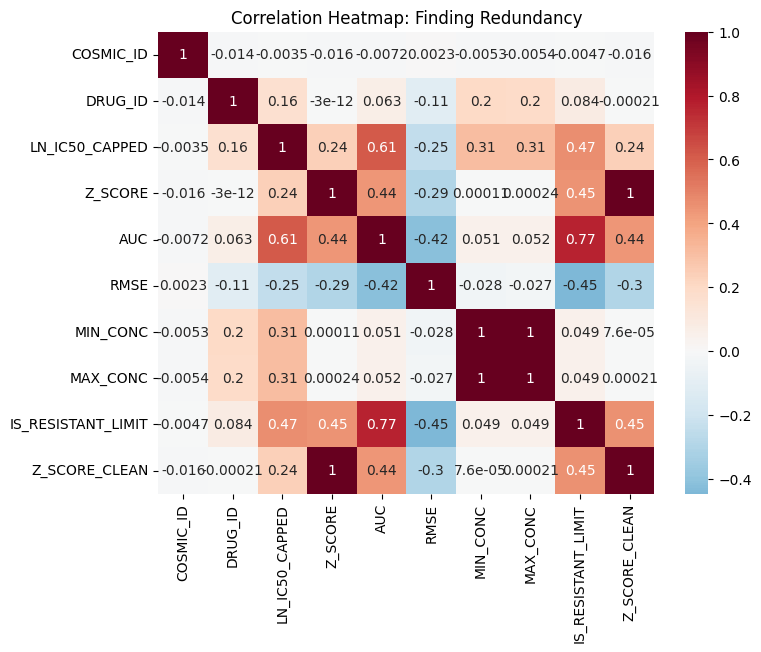

In [126]:
# Create a correlation heatmap to find 'Redundant' features
plt.figure(figsize=(8, 6))
sns.heatmap(df_merged.corr(numeric_only=True), annot=True, cmap='RdBu_r', center=0)
plt.title("Correlation Heatmap: Finding Redundancy")
plt.show()

In a predictive model, having two variables with a 1.0 correlation can make some models unstable. The variables with 1.0 correlation won't be have into account in the ML training models. 
* **Z-SCORE vs. Z_SCORE_CLEAN:** Drop the original Z_SCORE and keep the clean one.
* **MIN_CONC vs. MAX_CONC:** Drop MIN_CONC.

* **IS_RESISTANT_LIMIT:** Shouldn't be used for ML, this would commit data leakage. 

# BLOCK 5: Export cleaned data to BigQuery 

In [ ]:
# 1. Define destination 
table_id = "CGDA.fct_drug_sensitivity_CLEAN"

# 2. Upload the data
df_merged.to_gbq(
    destination_table=table_id, 
    project_id="tranquil-gasket-457509-b3",
     
    progress_bar=True
)